# Conditional GAN for MNIST Digit Generation

## Problem Statement

The goal of this notebook is to build a Conditional Generative Adversarial Network (cGAN) that learns to generate handwritten digit images from the MNIST dataset based on a specified digit label.

A standard GAN generates images from random noise only. A Conditional GAN adds extra information, such as a class label, to guide the generation process.

In this problem, the Generator receives both random noise and a digit label from 0 to 9. The Discriminator receives both an image and its label, then predicts whether the image is real or generated for that label.

## Objectives

By the end of this notebook, we will:

1. Load and preprocess the MNIST dataset with digit labels.
2. Build a Conditional Generator that creates images for requested labels.
3. Build a Conditional Discriminator that evaluates image-label pairs.
4. Train the cGAN using TensorFlow and Keras.
5. Generate synthetic handwritten digits for specific target classes.
6. Understand how class conditioning improves control over GAN outputs.

## Expected Outcome

After training, the Generator should produce synthetic 28x28 grayscale digit images that correspond to requested labels. For example, when the label is 7, the generated image should resemble a handwritten 7. With a small number of epochs, the images may be rough, but the label-guided structure should improve as training continues.

## 1. Import Required Libraries

This notebook uses TensorFlow/Keras, NumPy, and Matplotlib. These libraries are available in Google Colab.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models

# Make results reproducible across runs as much as possible.
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load and Preprocess the Dataset

We use MNIST handwritten digit images and their labels. Images are scaled to the range `[-1, 1]` because the Generator uses a `tanh` activation in the final layer.

In [ ]:
# Load MNIST training images and labels.
(x_train, y_train), (_, _) = tf.keras.datasets.mnist.load_data()

# Convert images to float32 for neural network training.
x_train = x_train.astype("float32")

# Scale image pixels from [0, 255] to [-1, 1].
x_train = (x_train - 127.5) / 127.5

# Flatten each 28x28 image into a vector of 784 pixel values.
x_train = x_train.reshape(x_train.shape[0], 784)

# Labels are integer class IDs from 0 to 9.
y_train = y_train.astype("int32")

print("Training image shape:", x_train.shape)
print("Training label shape:", y_train.shape)
print("Unique labels:", np.unique(y_train))
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training image shape: (60000, 784)
Training label shape: (60000,)
Unique labels: [0 1 2 3 4 5 6 7 8 9]
Minimum pixel value: -1.0
Maximum pixel value: 1.0


## 3. Define Hyperparameters

These settings control the model size, conditioning setup, and training duration. Increasing `EPOCHS` usually improves output quality.

In [ ]:
# Number of digit classes in MNIST.
NUM_CLASSES = 10

# Size of random noise vector provided to the Generator.
LATENT_DIM = 100

# Size of label embedding vectors used for conditioning.
EMBEDDING_DIM = 50

# Number of samples processed in each training step.
BATCH_SIZE = 128

# Number of complete passes through the training dataset.
EPOCHS = 10

# Optimizer settings commonly used for GAN training.
LEARNING_RATE = 0.0002
BETA_1 = 0.5

# Number of generated images to show during visualization.
NUM_EXAMPLES_TO_GENERATE = 10

## 4. Build the Conditional Generator

The Generator receives two inputs:

1. A random noise vector.
2. A digit label.

The label is converted into a dense embedding and concatenated with the noise vector. This combined input tells the Generator what type of digit to produce.

In [ ]:
def build_generator(latent_dim, num_classes, embedding_dim):
    """Builds a Conditional Generator model."""
    noise_input = layers.Input(shape=(latent_dim,), name="noise_input")
    label_input = layers.Input(shape=(), dtype="int32", name="label_input")

    # Convert the integer label into a learnable dense vector.
    label_embedding = layers.Embedding(num_classes, embedding_dim)(label_input)
    label_embedding = layers.Flatten()(label_embedding)

    # Combine random noise and label information.
    x = layers.Concatenate()([noise_input, label_embedding])

    # Dense layers transform the conditioned input into an image vector.
    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.BatchNormalization(momentum=0.8)(x)

    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.BatchNormalization(momentum=0.8)(x)

    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.BatchNormalization(momentum=0.8)(x)

    # The output is a flattened 28x28 image with values in [-1, 1].
    image_output = layers.Dense(784, activation="tanh", name="generated_image")(x)

    return models.Model([noise_input, label_input], image_output, name="Conditional_Generator")


generator = build_generator(LATENT_DIM, NUM_CLASSES, EMBEDDING_DIM)
generator.summary()

Model: "Conditional_Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label_input         │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50)        │        500 │ label_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_input         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 150)       │          0 │ noise_input[0][0… │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     38,656 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 256)       │          0 │ dense[0][0]       │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ leaky_re_lu[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    131,584 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 512)       │          0 │ dense_1[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ leaky_re_lu_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1024)      │    525,312 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 1024)      │          0 │ dense_2[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ leaky_re_lu_2[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generated_image     │ (None, 784)       │    803,600 │ batch_normalizat… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,506,820 (5.75 MB)

 Trainable params: 1,503,236 (5.73 MB)

 Non-trainable params: 3,584 (14.00 KB)

## 5. Build the Conditional Discriminator

The Discriminator receives two inputs:

1. An image vector.
2. The digit label associated with that image.

It learns whether the given image-label pair is real or generated.

In [ ]:
def build_discriminator(num_classes, embedding_dim):
    """Builds a Conditional Discriminator model."""
    image_input = layers.Input(shape=(784,), name="image_input")
    label_input = layers.Input(shape=(), dtype="int32", name="label_input")

    # Convert the label into a learnable vector.
    label_embedding = layers.Embedding(num_classes, embedding_dim)(label_input)
    label_embedding = layers.Flatten()(label_embedding)

    # Combine the image and label so the model can judge whether they match real data.
    x = layers.Concatenate()([image_input, label_embedding])

    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dropout(0.3)(x)

    # Output probability that the image-label pair is real.
    validity_output = layers.Dense(1, activation="sigmoid", name="validity")(x)

    return models.Model([image_input, label_input], validity_output, name="Conditional_Discriminator")


discriminator = build_discriminator(NUM_CLASSES, EMBEDDING_DIM)
discriminator.summary()

Model: "Conditional_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label_input         │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 50)        │        500 │ label_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 50)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 834)       │          0 │ image_input[0][0… │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 512)       │    427,520 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 512)       │          0 │ dense_3[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 256)       │          0 │ dense_4[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ leaky_re_lu_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ validity (Dense)    │ (None, 1)         │        257 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 559,605 (2.13 MB)

 Trainable params: 559,605 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Configure Loss Functions and Optimizers

The Discriminator learns to classify real image-label pairs as real and generated image-label pairs as fake.

The Generator learns to create images that the Discriminator classifies as real for the requested labels.

In [ ]:
# Binary cross-entropy is used for real-versus-fake classification.
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

generator_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=BETA_1)


def discriminator_loss(real_output, fake_output):
    """Calculates Discriminator loss for real and generated image-label pairs."""
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss


def generator_loss(fake_output):
    """Calculates Generator loss based on fooling the Discriminator."""
    return cross_entropy(tf.ones_like(fake_output), fake_output)

## 7. Prepare the Training Dataset

The dataset returns image-label pairs so both models can learn from class information.

In [ ]:
train_dataset = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train))
    .shuffle(buffer_size=x_train.shape[0])
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

print("Number of batches per epoch:", tf.data.experimental.cardinality(train_dataset).numpy())

Number of batches per epoch: 468


## 8. Define the Training Step

Each training step updates both networks:

1. The Generator creates images from random noise and sampled labels.
2. The Discriminator evaluates real image-label pairs and fake image-label pairs.
3. The Discriminator is updated to improve classification.
4. The Generator is updated to make generated images more realistic for their labels.

In [ ]:
@tf.function
def train_step(real_images, real_labels):
    """Runs one cGAN training step for a batch of image-label pairs."""
    batch_size = tf.shape(real_images)[0]

    # Sample random noise and random target labels for generated images.
    noise = tf.random.normal([batch_size, LATENT_DIM])
    fake_labels = tf.random.uniform([batch_size], minval=0, maxval=NUM_CLASSES, dtype=tf.int32)

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Generate fake images conditioned on fake_labels.
        generated_images = generator([noise, fake_labels], training=True)

        # Evaluate real and fake image-label pairs.
        real_output = discriminator([real_images, real_labels], training=True)
        fake_output = discriminator([generated_images, fake_labels], training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

## 9. Helper Function to Display Label-Controlled Images

This function generates one image for each digit label from 0 to 9. A fixed noise input is used to make progress easier to compare across epochs.

In [ ]:
# Fixed noise and fixed labels for consistent visualization.
seed_noise = tf.random.normal([NUM_EXAMPLES_TO_GENERATE, LATENT_DIM])
seed_labels = tf.constant(np.arange(NUM_EXAMPLES_TO_GENERATE), dtype=tf.int32)


def display_generated_images(model, epoch, noise, labels):
    """Displays generated images for the supplied labels."""
    predictions = model([noise, labels], training=False)

    # Convert from [-1, 1] back to [0, 1] for display.
    predictions = (predictions + 1.0) / 2.0
    predictions = tf.reshape(predictions, [-1, 28, 28])

    plt.figure(figsize=(10, 2))

    for i in range(predictions.shape[0]):
        plt.subplot(1, NUM_EXAMPLES_TO_GENERATE, i + 1)
        plt.imshow(predictions[i], cmap="gray")
        plt.title(f"Label {int(labels[i])}")
        plt.axis("off")

    plt.suptitle(f"Conditional Generated Images After Epoch {epoch}")
    plt.tight_layout()
    plt.show()

## 10. Train the Conditional GAN

GAN losses can fluctuate because the Generator and Discriminator are trained as competing models. Generated image quality should be monitored visually in addition to checking loss values.

Epoch 01/10 | Generator Loss: 2.6891 | Discriminator Loss: 0.5284


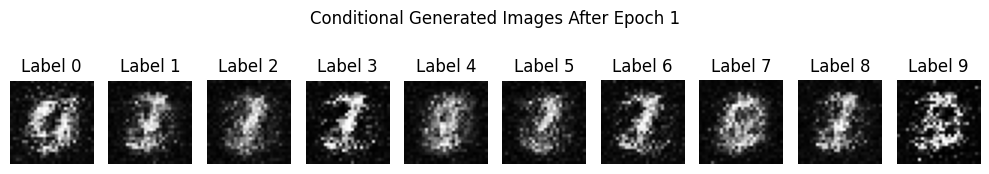

Epoch 02/10 | Generator Loss: 1.0015 | Discriminator Loss: 1.1358
Epoch 03/10 | Generator Loss: 1.1251 | Discriminator Loss: 1.0428
Epoch 04/10 | Generator Loss: 1.1629 | Discriminator Loss: 1.0439
Epoch 05/10 | Generator Loss: 1.1727 | Discriminator Loss: 1.0406


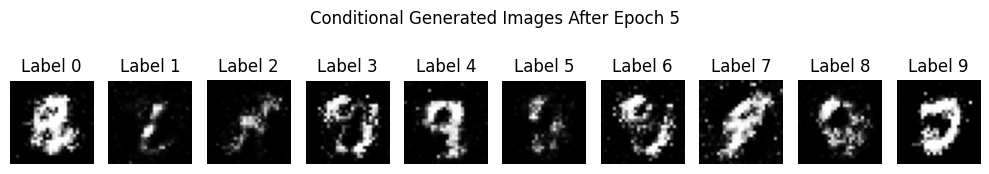

Epoch 06/10 | Generator Loss: 1.1656 | Discriminator Loss: 1.0619
Epoch 07/10 | Generator Loss: 1.0380 | Discriminator Loss: 1.1549
Epoch 08/10 | Generator Loss: 0.9581 | Discriminator Loss: 1.2035
Epoch 09/10 | Generator Loss: 0.9164 | Discriminator Loss: 1.2381
Epoch 10/10 | Generator Loss: 0.8805 | Discriminator Loss: 1.2619


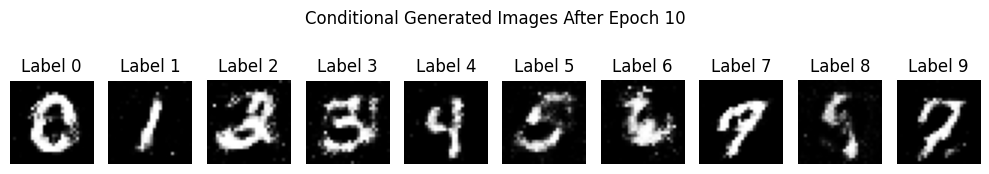

In [ ]:
def train(dataset, epochs):
    """Trains the Conditional GAN and displays generated samples during training."""
    generator_losses = []
    discriminator_losses = []

    for epoch in range(1, epochs + 1):
        epoch_gen_losses = []
        epoch_disc_losses = []

        for image_batch, label_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch, label_batch)
            epoch_gen_losses.append(gen_loss.numpy())
            epoch_disc_losses.append(disc_loss.numpy())

        avg_gen_loss = float(np.mean(epoch_gen_losses))
        avg_disc_loss = float(np.mean(epoch_disc_losses))
        generator_losses.append(avg_gen_loss)
        discriminator_losses.append(avg_disc_loss)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Generator Loss: {avg_gen_loss:.4f} | "
            f"Discriminator Loss: {avg_disc_loss:.4f}"
        )

        # Display images at the first epoch, every 5 epochs, and the final epoch.
        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            display_generated_images(generator, epoch, seed_noise, seed_labels)

    return generator_losses, discriminator_losses


generator_losses, discriminator_losses = train(train_dataset, EPOCHS)

## 11. Plot Training Losses

The plot shows Generator and Discriminator loss across epochs. In GAN training, these curves are useful for monitoring, but image quality is often the most important evaluation signal.

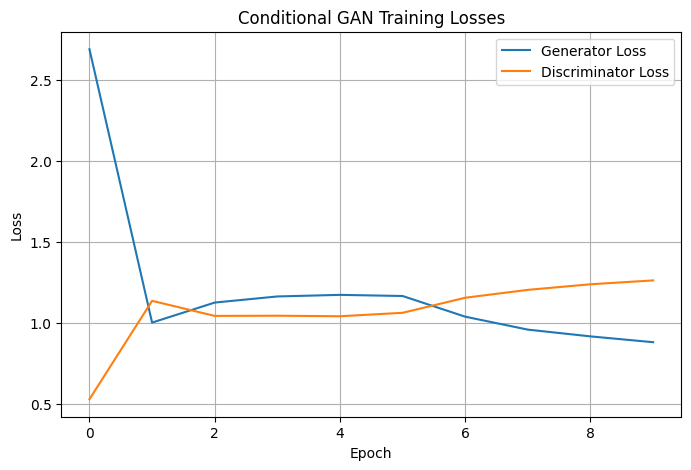

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(generator_losses, label="Generator Loss")
plt.plot(discriminator_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Conditional GAN Training Losses")
plt.legend()
plt.grid(True)
plt.show()

## 12. Generate Digits for Selected Labels

The trained Generator can create images for any requested digit label from 0 to 9.

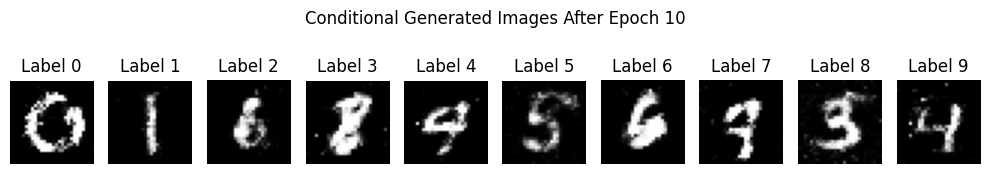

In [ ]:
# Request one generated sample for each digit class.
requested_labels = tf.constant([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=tf.int32)
new_noise = tf.random.normal([len(requested_labels), LATENT_DIM])

display_generated_images(generator, EPOCHS, new_noise, requested_labels)

## Conclusion

This notebook implemented a Conditional GAN for label-controlled handwritten digit generation using the MNIST dataset. Unlike a Vanilla GAN, the Conditional GAN receives class labels as part of both the Generator and Discriminator inputs.

The Generator learned to produce synthetic digit images based on requested labels, while the Discriminator learned to judge whether each image-label pair was real or generated.

This approach provides more control over generated outputs and forms the foundation for more advanced conditional generation tasks, such as class-guided image synthesis, text-guided generation, and image-to-image translation.